In [1]:
import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt

In [ ]:
# Importting NSDUH dataset

In [21]:
df = pd.read_csv("nsduh.csv", usecols=['YEAR', 'QUESTID2','UDALBLCKOUT', 'IRALCBNG30D'])

In [ ]:
# UDALBLCKOUT: During the past 12 months, did you repeatedly have blackouts while drinking or after drinking alcohol?
# IRALCBNG30D: The number of days in the past month on which the respondent reported drinking five or
# more drinks on the same occasion for males or four or more drinks on the same occasion for females. For this variable, "occasion" means at the
# same time or within a couple hours of each other. 

In [22]:
df.head(10)

,YEAR,IRALCBNG30D,UDALBLCKOUT,QUESTID2
0,2021,93,2,10000190
1,2021,93,93,10000379
2,2021,0,93,10002714
3,2021,93,93,10004444
4,2021,91,91,10005021
5,2021,93,93,10005756
6,2021,0,2,10006048
7,2021,0,2,10006934
8,2021,91,91,10008556
9,2021,93,93,10008909


In [23]:
# Check duplicates
duplicates = df.duplicated(subset=['YEAR', 'QUESTID2']).sum()
print("Number of duplicates:")
print(duplicates)

Number of duplicates:
0


In [24]:
# Filtering blackout row to only respondants said Yes(1) or No(0)
df_new = df[df['UDALBLCKOUT'].isin([1, 2])].copy()
df_new['AIB'] = df_new['UDALBLCKOUT'].replace({2: 0})

In [25]:
# Map the "non-drinker" codes to 0 binge days.
# 91 = Never used alcohol -> 0
# 93 = Did not use alcohol past month -> 0
df_new['Binge_Days'] = df_new['IRALCBNG30D'].replace({91:0, 93:0})

In [26]:
# Checking missing values
print("Number of missing values:")
df_new.isnull().sum()

Number of missing values:


YEAR           0
IRALCBNG30D    0
UDALBLCKOUT    0
QUESTID2       0
AIB            0
Binge_Days     0
dtype: int64

In [28]:
# Dropping unused columns
df_new = df_new.drop(columns=['YEAR', 'IRALCBNG30D', 'UDALBLCKOUT', 'QUESTID2'])

In [31]:
# Bayesian Logistic Regression model
model = bmb.Model("AIB ~ Binge_Days", df_new, family="bernoulli")
fitted = model.fit(draws=1000, tune=1000, chains=4, target_accept=0.9)

Modeling the probability that AIB==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [Intercept, Binge_Days]


/opt/anaconda3/envs/bayes/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 833 seconds.


In [32]:
az.summary(fitted)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.641,0.019,-3.677,-3.605,0.0,0.0,2677.0,2684.0,1.0
Binge_Days,0.106,0.002,0.102,0.111,0.0,0.0,2976.0,2731.0,1.0


In [ ]:
# Binge_Days is non_zero, r_hat = 1.0, everything looks good

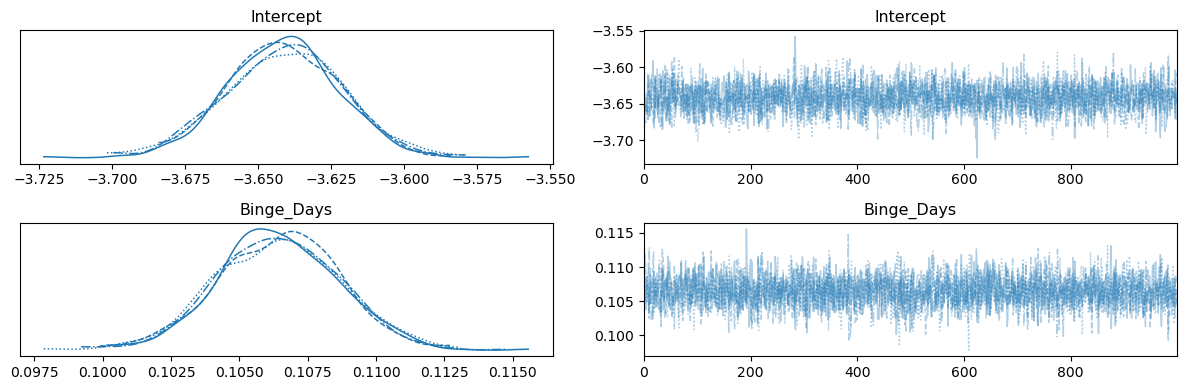

In [33]:
# Check for convergence
az.plot_trace(fitted, var_names=['Intercept','Binge_Days'])
plt.tight_layout()
plt.show()

In [35]:
# Pass over the  means from Intercept (-3.641) and Binge_Days (0.106)